# PK Figure -> CSV

Extract observed data points from pharmacokinetic time-concentration plots and save them to a CSV that can later be re-plotted.

**Workflow**

1. Inspect the image.
2. Calibrate the axes by clicking the origin and the x/y endpoints (3 clicks) -- or the 4-click backup with two x-axis points and two y-axis points.
3. For each trajectory in the figure, click on the centre of every observed point. Right-click to undo the last click.
4. Optionally, click the endpoint of each one-sided error bar to capture the SE.
5. Save the result to a tidy CSV: `trajectory, x, y, se`.
6. Re-plot from the CSV to verify the extraction.

**Backend.** This notebook uses interactive matplotlib clicks. Install `ipympl` (`pip install ipympl`) and keep the `%matplotlib widget` magic below. If you prefer a separate window, swap it for `%matplotlib qt` or `%matplotlib tk`.


In [22]:
%matplotlib widget
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

## The extractor

A small state machine around a matplotlib figure: calibration records the pixel-to-data mapping, `start_trajectory` / `finish_trajectory` collect the observed points for one curve, `start_se_extraction` / `finish_se_extraction` optionally capture one-sided error bars, and `save_csv` writes a tidy `trajectory, x, y, se` table.


In [23]:
class PKFigureExtractor:
    """Click-based extractor for time-concentration plots. Linear axes only."""

    def __init__(self, image_path):
        self.image_path = Path(image_path)
        self.img = np.array(Image.open(self.image_path).convert("RGB"))
        self.x_refs = None  # [(pixel_x, data_x), (pixel_x, data_x)]
        self.y_refs = None  # [(pixel_y, data_y), (pixel_y, data_y)]
        self.trajectories = {}      # name -> list of (x_data, y_data)
        self.standard_errors = {}   # name -> list of SE magnitudes (aligned with trajectories[name])
        self._fig = None
        self._ax = None
        self._cid = None
        self._mode = None
        self._pending = []
        self._pending_meta = None

    # ---------- figure helpers ----------
    def _open(self, title):
        if self._fig is not None:
            plt.close(self._fig)
        self._fig, self._ax = plt.subplots(figsize=(11, 8))
        self._ax.imshow(self.img)
        self._ax.set_xticks([]); self._ax.set_yticks([])
        self._ax.set_title(title, fontsize=11)
        return self._fig, self._ax

    def _connect(self, handler):
        if self._cid is not None and self._fig is not None:
            self._fig.canvas.mpl_disconnect(self._cid)
        self._cid = self._fig.canvas.mpl_connect("button_press_event", handler)

    # ---------- coordinate conversion (linear) ----------
    def pixel_to_data(self, px, py):
        if self.x_refs is None or self.y_refs is None:
            raise RuntimeError("Axes not calibrated yet.")
        (xpa, xva), (xpb, xvb) = self.x_refs
        x = xva + (px - xpa) * (xvb - xva) / (xpb - xpa)
        (ypa, yva), (ypb, yvb) = self.y_refs
        y = yva + (py - ypa) * (yvb - yva) / (ypb - ypa)
        return x, y

    def _data_to_pixel(self, x, y):
        (xpa, xva), (xpb, xvb) = self.x_refs
        px = xpa + (x - xva) * (xpb - xpa) / (xvb - xva)
        (ypa, yva), (ypb, yvb) = self.y_refs
        py = ypa + (y - yva) * (ypb - ypa) / (yvb - yva)
        return px, py

    # ---------- step 1: inspect ----------
    def show(self):
        self._open(self.image_path.name)

    # ---------- step 2: calibrate ----------
    def calibrate(self, x_refs, y_refs):
        """4-click calibration: click 2 known x-axis points, then 2 known y-axis points."""
        self._mode = "calibrate"
        self._pending = []
        order = [f"x = {x_refs[0]}", f"x = {x_refs[1]}",
                 f"y = {y_refs[0]}", f"y = {y_refs[1]}"]
        fig, ax = self._open(f"Calibrate (1/4): click {order[0]}")

        def on_click(event):
            if event.inaxes != ax or event.xdata is None:
                return
            i = len(self._pending)
            self._pending.append((event.xdata, event.ydata))
            colour = "tab:red" if i < 2 else "tab:blue"
            ax.plot(event.xdata, event.ydata, marker="+", ms=18, mew=2.4, color=colour)
            ax.annotate(order[i], (event.xdata, event.ydata),
                        xytext=(8, -8), textcoords="offset points",
                        fontsize=9, color=colour)
            if i + 1 < 4:
                ax.set_title(f"Calibrate ({i+2}/4): click {order[i+1]}", fontsize=11)
            else:
                xpa, _ = self._pending[0]
                xpb, _ = self._pending[1]
                _, ypa = self._pending[2]
                _, ypb = self._pending[3]
                self.x_refs = [(xpa, x_refs[0]), (xpb, x_refs[1])]
                self.y_refs = [(ypa, y_refs[0]), (ypb, y_refs[1])]
                ax.set_title("Axes calibrated -- ready to extract trajectories.",
                             fontsize=11, color="tab:green")
                fig.canvas.mpl_disconnect(self._cid)
                self._cid = None
                self._mode = None
            fig.canvas.draw_idle()

        self._connect(on_click)

    def calibrate_corners(self, x_end, y_end, origin=(0, 0)):
        """3-click calibration: click the origin, then a known x-axis endpoint,
        then a known y-axis endpoint.

        Args:
            x_end: x-data value at the second click.
            y_end: y-data value at the third click.
            origin: (x_data, y_data) at the first click. Defaults to (0, 0).
        """
        ox, oy = origin
        self._mode = "calibrate"
        self._pending = []
        order = [f"origin (x={ox}, y={oy})", f"x = {x_end}", f"y = {y_end}"]
        colours = ["tab:purple", "tab:red", "tab:blue"]
        fig, ax = self._open(f"Calibrate (1/3): click {order[0]}")

        def on_click(event):
            if event.inaxes != ax or event.xdata is None:
                return
            i = len(self._pending)
            self._pending.append((event.xdata, event.ydata))
            colour = colours[i]
            ax.plot(event.xdata, event.ydata, marker="+", ms=18, mew=2.4, color=colour)
            ax.annotate(order[i], (event.xdata, event.ydata),
                        xytext=(8, -8), textcoords="offset points",
                        fontsize=9, color=colour)
            if i + 1 < 3:
                ax.set_title(f"Calibrate ({i+2}/3): click {order[i+1]}", fontsize=11)
            else:
                opx, opy = self._pending[0]
                xpx, _ = self._pending[1]
                _, ypy = self._pending[2]
                self.x_refs = [(opx, ox), (xpx, x_end)]
                self.y_refs = [(opy, oy), (ypy, y_end)]
                ax.set_title("Axes calibrated -- ready to extract trajectories.",
                             fontsize=11, color="tab:green")
                fig.canvas.mpl_disconnect(self._cid)
                self._cid = None
                self._mode = None
            fig.canvas.draw_idle()

        self._connect(on_click)

    # ---------- step 3: trajectories ----------
    def start_trajectory(self, name):
        if self.x_refs is None or self.y_refs is None:
            raise RuntimeError("Calibrate the axes first.")
        self._mode = "trajectory"
        self._pending = []
        self._pending_meta = name
        fig, ax = self._open(
            f"Trajectory '{name}': left-click each observed point, right-click to undo. "
            f"Then run finish_trajectory()."
        )
        for tname, pts in self.trajectories.items():
            xs, ys = zip(*[self._data_to_pixel(x, y) for x, y in pts])
            ax.plot(xs, ys, "o", ms=5, mfc="none", mec="gray", alpha=0.4)

        def redraw():
            ax.cla()
            ax.imshow(self.img)
            ax.set_xticks([]); ax.set_yticks([])
            for tname, pts in self.trajectories.items():
                xs, ys = zip(*[self._data_to_pixel(x, y) for x, y in pts])
                ax.plot(xs, ys, "o", ms=5, mfc="none", mec="gray", alpha=0.4)
            if self._pending:
                xs, ys = zip(*self._pending)
                ax.plot(xs, ys, "o", ms=8, mfc="none", mec="red", mew=2)
            ax.set_title(
                f"Trajectory '{name}': {len(self._pending)} points "
                f"(right-click undo, then finish_trajectory())", fontsize=11,
            )
            fig.canvas.draw_idle()

        def on_click(event):
            if event.inaxes != ax or event.xdata is None:
                return
            if event.button == 3:
                if self._pending:
                    self._pending.pop()
                    redraw()
                return
            self._pending.append((event.xdata, event.ydata))
            ax.plot(event.xdata, event.ydata, "o", ms=8, mfc="none", mec="red", mew=2)
            ax.set_title(
                f"Trajectory '{name}': {len(self._pending)} points "
                f"(right-click undo, then finish_trajectory())", fontsize=11,
            )
            fig.canvas.draw_idle()

        self._connect(on_click)

    def finish_trajectory(self):
        if self._mode != "trajectory":
            raise RuntimeError("No trajectory in progress.")
        name = self._pending_meta
        pts = sorted(
            (self.pixel_to_data(px, py) for px, py in self._pending),
            key=lambda p: p[0],
        )
        self.trajectories[name] = pts
        if self._cid is not None:
            self._fig.canvas.mpl_disconnect(self._cid)
            self._cid = None
        self._ax.set_title(
            f"Trajectory '{name}' captured: {len(pts)} points.",
            color="tab:green", fontsize=11,
        )
        self._fig.canvas.draw_idle()
        self._mode = None
        return pts

    # ---------- step 3.5: one-sided standard-error bars ----------
    def start_se_extraction(self, name):
        """Click the endpoint of each one-sided error bar for an already-extracted
        trajectory. Each click is paired with the data point whose x is closest to
        the click. The SE magnitude stored is |endpoint_y - mean_y| in data units.
        Right-click undoes the last click. Run finish_se_extraction() when done."""
        if self.x_refs is None or self.y_refs is None:
            raise RuntimeError("Calibrate the axes first.")
        if name not in self.trajectories:
            raise ValueError(
                f"Trajectory '{name}' not extracted yet -- run start_trajectory(...) first."
            )
        pts = self.trajectories[name]
        if not pts:
            raise ValueError(f"Trajectory '{name}' has no points.")
        self._mode = "se"
        self._pending = []  # list of (data_idx, endpoint_px, endpoint_py)
        self._pending_meta = name

        pts_pixel = [self._data_to_pixel(x, y) for x, y in pts]

        fig, ax = self._open(
            f"SE for '{name}': click each error-bar endpoint (any order). "
            f"Each click pairs with the nearest data point (by x). "
            f"Right-click undo, then finish_se_extraction()."
        )

        def draw_markers():
            for i, (mpx, mpy) in enumerate(pts_pixel):
                ax.plot(mpx, mpy, "o", ms=8, mfc="none", mec="lime", mew=1.5)
                ax.annotate(str(i + 1), (mpx, mpy),
                            xytext=(6, -6), textcoords="offset points",
                            fontsize=8, color="lime")
        draw_markers()

        def redraw():
            ax.cla()
            ax.imshow(self.img)
            ax.set_xticks([]); ax.set_yticks([])
            draw_markers()
            for data_idx, epx, epy in self._pending:
                mpx, mpy = pts_pixel[data_idx]
                ax.plot([mpx, epx], [mpy, epy], "r-", lw=1.2)
                ax.plot(epx, epy, "+", color="red", ms=14, mew=2)
            ax.set_title(
                f"SE for '{name}': {len(self._pending)}/{len(pts)} captured "
                f"(right-click undo, then finish_se_extraction())", fontsize=11,
            )
            fig.canvas.draw_idle()

        def on_click(event):
            if event.inaxes != ax or event.xdata is None:
                return
            if event.button == 3:
                if self._pending:
                    self._pending.pop()
                    redraw()
                return
            closest = min(range(len(pts_pixel)),
                          key=lambda i: abs(pts_pixel[i][0] - event.xdata))
            self._pending.append((closest, event.xdata, event.ydata))
            mpx, mpy = pts_pixel[closest]
            ax.plot([mpx, epx := event.xdata], [mpy, epy := event.ydata], "r-", lw=1.2)
            ax.plot(epx, epy, "+", color="red", ms=14, mew=2)
            ax.set_title(
                f"SE for '{name}': {len(self._pending)}/{len(pts)} captured "
                f"(right-click undo, then finish_se_extraction())", fontsize=11,
            )
            fig.canvas.draw_idle()

        self._connect(on_click)

    def finish_se_extraction(self):
        if self._mode != "se":
            raise RuntimeError("No SE extraction in progress.")
        name = self._pending_meta
        pts = self.trajectories[name]
        se_list = [None] * len(pts)
        for data_idx, epx, epy in self._pending:
            _, end_y = self.pixel_to_data(epx, epy)
            _, mean_y = pts[data_idx]
            se_list[data_idx] = abs(end_y - mean_y)  # last click wins for dupes
        self.standard_errors[name] = se_list
        if self._cid is not None:
            self._fig.canvas.mpl_disconnect(self._cid)
            self._cid = None
        n_captured = sum(1 for s in se_list if s is not None)
        self._ax.set_title(
            f"SE for '{name}' captured: {n_captured}/{len(pts)} points have SE.",
            color="tab:green", fontsize=11,
        )
        self._fig.canvas.draw_idle()
        self._mode = None
        return se_list

    # ---------- step 4 / 5: export and verify ----------
    def to_dataframe(self):
        rows = []
        for name, pts in self.trajectories.items():
            ses = self.standard_errors.get(name, [None] * len(pts))
            for (x, y), se in zip(pts, ses):
                rows.append({
                    "trajectory": name, "x": x, "y": y,
                    "se": np.nan if se is None else se,
                })
        return pd.DataFrame(rows)

    def save_csv(self, path):
        df = self.to_dataframe()
        df.to_csv(path, index=False)
        return df

    def replot(self, ax=None, x_label="x", y_label="y"):
        if ax is None:
            _, ax = plt.subplots(figsize=(8, 6))
        for name, pts in self.trajectories.items():
            xs, ys = zip(*pts)
            ses = self.standard_errors.get(name)
            if ses is not None:
                yerr = [s if s is not None else 0.0 for s in ses]
                ax.errorbar(xs, ys, yerr=yerr, fmt="o-", label=name, alpha=0.85,
                            capsize=3, elinewidth=1)
            else:
                ax.plot(xs, ys, "o-", label=name, alpha=0.85)
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.grid(True, ls=":", alpha=0.5)
        ax.legend(fontsize=8, loc="best")
        ax.set_title("Re-plotted from extracted CSV")
        return ax


## 1. Configure and inspect

Set the image path and output CSV path below, then run the cell to display the figure. Linear axes only.


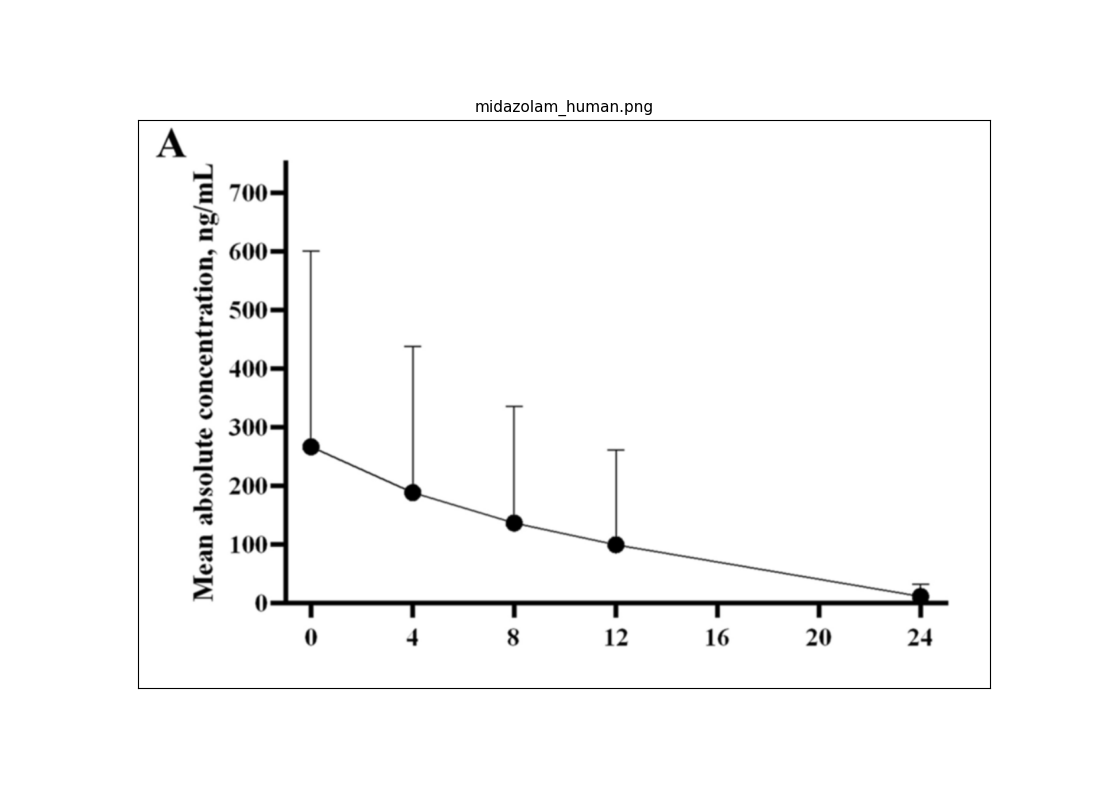

In [100]:
IMAGE_PATH = "example_images/midazolam_human.png"
OUTPUT_CSV = "extracted_data/midazolam.csv"

extractor = PKFigureExtractor(IMAGE_PATH)
extractor.show()


## 2. Calibrate the axes

**Default: 3-click calibration** (`calibrate_corners`). Click the *origin* of the plot (where the x and y axis spines meet), then a known x-axis endpoint, then a known y-axis endpoint. Three clicks total.

- Pass the data values at the x and y endpoints via `x_end` and `y_end`.
- For plots whose origin isn't at (0, 0), pass `origin=(x0, y0)`.

**Backup: 4-click calibration** (`calibrate`). Use this when the origin isn't a single visible point, e.g. when x=0 is off-screen, or when the x-axis spine doesn't extend back to the data origin. Click two known x-axis points, then two known y-axis points.

Both methods write the same `self.x_refs` / `self.y_refs`, so everything downstream works identically.


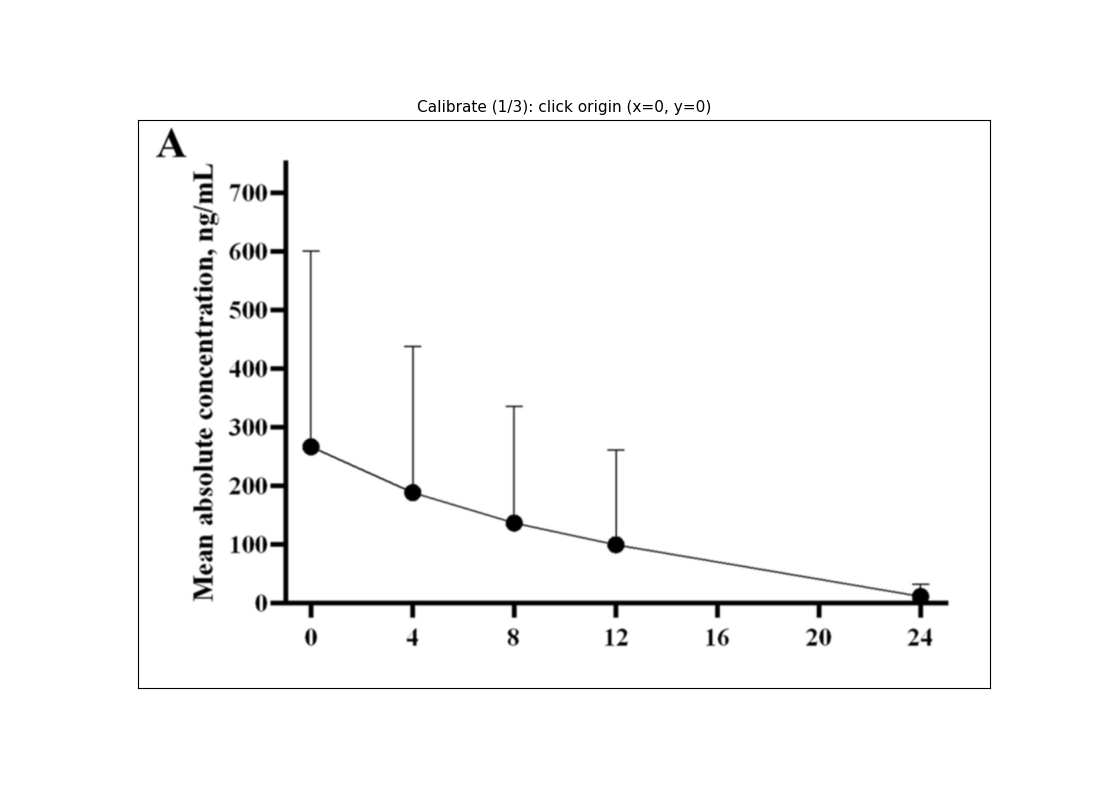

In [101]:
# 3-click calibration: origin -> x endpoint -> y endpoint.
# Backup is the original 4-click extractor.calibrate(x_refs=..., y_refs=...).
extractor.calibrate_corners(x_end=24, y_end=700, origin=(0, 0))

## 3. Extract each trajectory

For every curve in the figure:

1. Run `start_trajectory("<name>")`. The figure re-opens; previously captured points are shown as faint grey rings.
2. Left-click the centre of each observed marker. Right-click to undo the last click.
3. Run `finish_trajectory()` to commit the curve.

Repeat for every trajectory in the legend. Duplicate the cells below as needed.

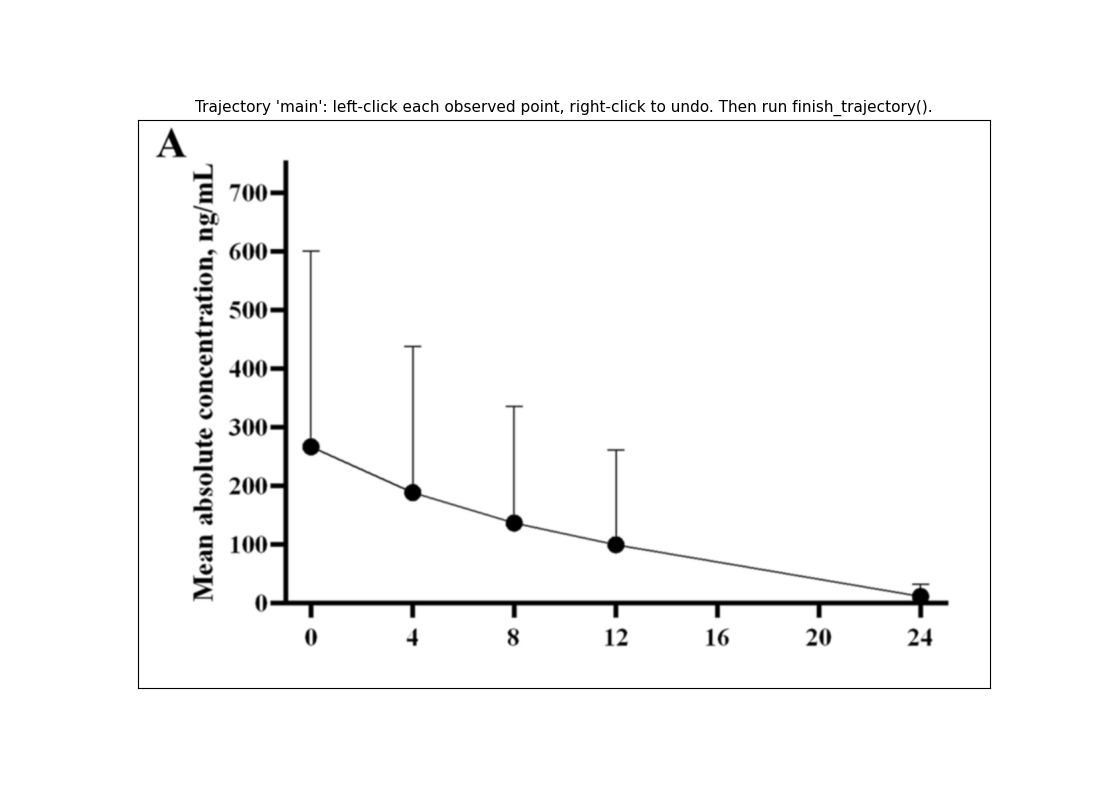

In [102]:
extractor.start_trajectory("main")

In [103]:
extractor.finish_trajectory()

[(np.float64(0.0), np.float64(271.46341463414643)),
 (np.float64(4.052459016393443), np.float64(189.51219512195132)),
 (np.float64(7.947540983606557), np.float64(141.70731707317077)),
 (np.float64(12.078688524590163), np.float64(107.56097560975611)),
 (np.float64(24.039344262295085), np.float64(10.243902439024355))]

## 3b. (Optional) Standard-error bars

Many PK plots draw a single one-sided error bar at each marker -- the SE is symmetric, so the figure only shows one side to save space. For any trajectory you've already extracted, you can capture those error bars now:

1. Run `extractor.start_se_extraction("<name>")`. The figure re-opens with the trajectory's data points marked in lime and numbered.
2. Click the *endpoint* of each one-sided error bar. Each click is paired with the nearest data point in x, so the order doesn't matter -- click the bars in whichever order is easiest.
3. Right-click to undo the last endpoint. Re-click an already-captured point to overwrite it.
4. Run `extractor.finish_se_extraction()` to commit. The SE magnitude stored is `|endpoint_y - mean_y|` in data units (the direction of the bar doesn't matter -- the magnitude is what's statistically meaningful).

If you skip this for a trajectory, its `se` column in the CSV will be NaN. Duplicate the cells below for each trajectory whose error bars you want to capture.

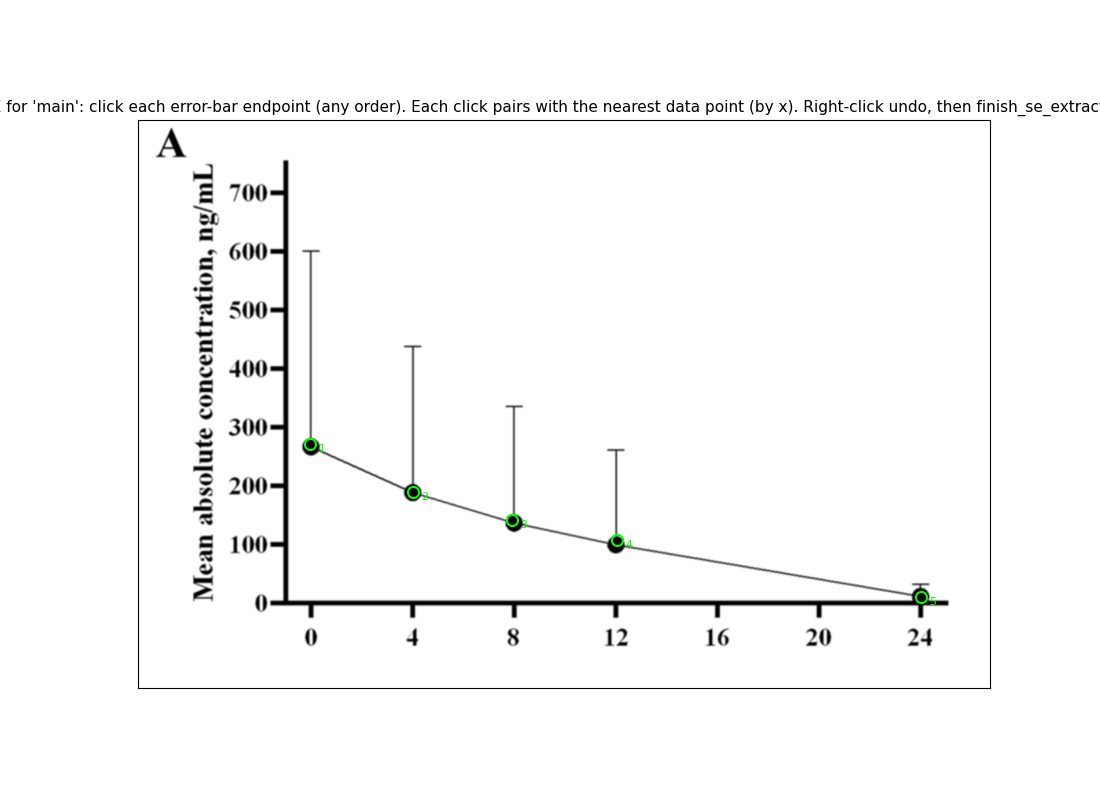

In [104]:
extractor.start_se_extraction("main")

In [105]:
extractor.finish_se_extraction()

[np.float64(329.51219512195115),
 np.float64(249.2682926829267),
 np.float64(196.34146341463418),
 np.float64(153.65853658536582),
 np.float64(20.48780487804884)]

## 4. Save to CSV

In [106]:
df = extractor.save_csv(OUTPUT_CSV)
print(f"Saved {len(df)} points across {df['trajectory'].nunique()} trajectories to {OUTPUT_CSV}")
df.head(20)

Saved 5 points across 1 trajectories to extracted_midazolam.csv


,trajectory,x,y,se
0,main,0.000000,271.463415,329.512195
1,main,4.052459,189.512195,249.268293
2,main,7.947541,141.707317,196.341463
3,main,12.078689,107.560976,153.658537
4,main,24.039344,10.243902,20.487805


## 5. Re-plot from the CSV

Round-trip check: load the CSV back from disk and reconstruct the plot. If the calibration was right, the reconstructed plot should look like the original.

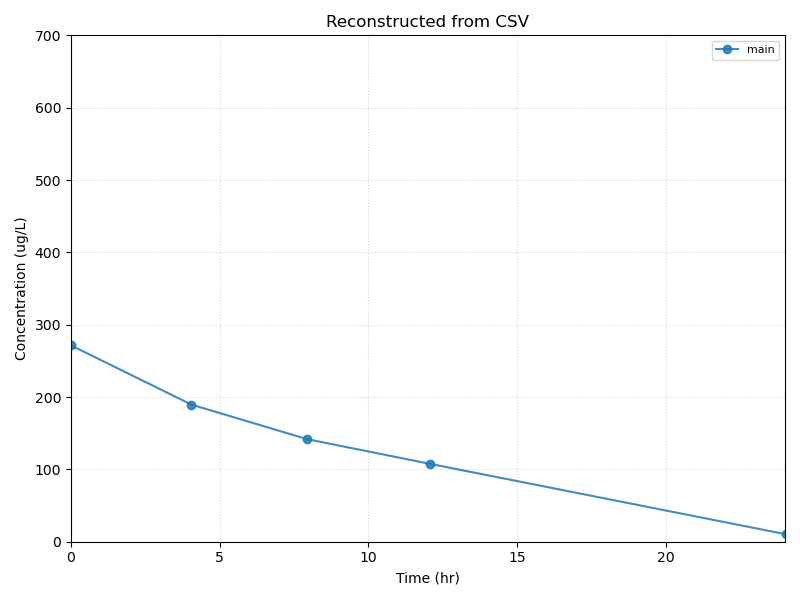

In [108]:
loaded = pd.read_csv(OUTPUT_CSV)

fig, ax = plt.subplots(figsize=(8, 6))
for name, group in loaded.groupby("trajectory", sort=False):
    ax.plot(group["x"], group["y"], "o-", label=name, alpha=0.85)
ax.set_xlabel("Time (hr)")
ax.set_ylabel("Concentration (ug/L)")
ax.grid(True, ls=":", alpha=0.5)
ax.legend(fontsize=8, loc="best")
ax.set_title("Reconstructed from CSV")
ax.set_ylim(0, 700)
ax.set_xlim(0, 24)
fig.tight_layout()